In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load dataset
df = pd.read_csv('patient.csv')

# Preview data
print(df.head())


   id     sex  birth_year country               region group infection_reason  \
0   1  female      1984.0   China  filtered at airport   NaN   visit to Wuhan   
1   2    male      1964.0   Korea  filtered at airport   NaN   visit to Wuhan   
2   3    male      1966.0   Korea         capital area   NaN   visit to Wuhan   
3   4    male      1964.0   Korea         capital area   NaN   visit to Wuhan   
4   5    male      1987.0   Korea         capital area   NaN   visit to Wuhan   

   infection_order  infected_by  contact_number confirmed_date released_date  \
0              1.0          NaN            45.0     2020-01-20    2020-02-06   
1              1.0          NaN            75.0     2020-01-24    2020-02-05   
2              1.0          NaN            16.0     2020-01-26    2020-02-12   
3              1.0          NaN            95.0     2020-01-27    2020-02-09   
4              1.0          NaN            31.0     2020-01-30           NaN   

  deceased_date     state  
0   

In [6]:
# Structure of dataset
print("\nDataset Info:")
print(df.info())

# Basic statistics
print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB
None

Summary Statistics:
                id   birth_year  inf

Data Cleaning

In [7]:
# Convert date columns to datetime
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'], errors='coerce')
df['released_date'] = pd.to_datetime(df['released_date'], errors='coerce')
df['deceased_date'] = pd.to_datetime(df['deceased_date'], errors='coerce')


In [8]:
# Create AGE column
current_year = 2020  # since dataset is from 2020 outbreak
df['age'] = current_year - df['birth_year']

# Handle invalid ages
df.loc[(df['age'] < 0) | (df['age'] > 120), 'age'] = np.nan

# Clean 'sex' column (standardize)
df['sex'] = df['sex'].str.lower()

In [9]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
id                     0
sex                 3894
birth_year          3920
country                0
region              3907
group               4136
infection_reason    4082
infection_order     4177
infected_by         4150
contact_number      4180
confirmed_date         0
released_date       4184
deceased_date       4199
state                  0
age                 3920
dtype: int64


In [10]:
print(df[['age', 'sex', 'confirmed_date']].head())

    age     sex confirmed_date
0  36.0  female     2020-01-20
1  56.0    male     2020-01-24
2  54.0    male     2020-01-26
3  56.0    male     2020-01-27
4  33.0    male     2020-01-30


Feature Engineering

In [11]:
# Create recovery_days
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

# Create a separate dataset for recovery analysis (VERY IMPORTANT)
recovery_df = df[df['recovery_days'].notnull()]

# Remove negative or unrealistic values
recovery_df = recovery_df[recovery_df['recovery_days'] >= 0]

# Check result
print("Recovery Data Shape:", recovery_df.shape)
print(recovery_df[['confirmed_date', 'released_date', 'recovery_days']].head())

Recovery Data Shape: (28, 16)
  confirmed_date released_date  recovery_days
0     2020-01-20    2020-02-06           17.0
1     2020-01-24    2020-02-05           12.0
2     2020-01-26    2020-02-12           17.0
3     2020-01-27    2020-02-09           13.0
5     2020-01-30    2020-02-19           20.0


In [12]:
print("\nRecovery Days Stats:")
print(recovery_df['recovery_days'].describe())


Recovery Days Stats:
count    28.000000
mean     15.107143
std       5.626256
min       7.000000
25%       9.750000
50%      16.000000
75%      19.250000
max      24.000000
Name: recovery_days, dtype: float64


In [13]:
#save recovery dataset
recovery_df.to_csv("recovery_data.csv", index=False)

Data Cleaning (more Precise)

In [14]:
# Create a cleaner version for EDA
eda_df = df.copy()

# Drop rows where key fields are missing
eda_df = eda_df.dropna(subset=['sex', 'age', 'region'])

# Optional: fill missing infection_reason with 'Unknown'
eda_df['infection_reason'] = eda_df['infection_reason'].fillna('Unknown')

# Check shape
print("EDA Data Shape:", eda_df.shape)

EDA Data Shape: (272, 16)


In [15]:
# save cleaned EDA dataset
eda_df.to_csv("cleaned_eda_data.csv", index=False)

EDA

Gender Distribution

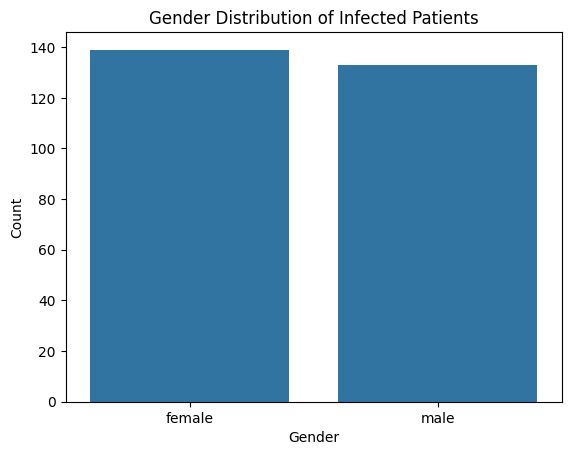

sex
female    139
male      133
Name: count, dtype: int64


In [16]:
# Gender count
plt.figure()
sns.countplot(data=eda_df, x='sex')
plt.title("Gender Distribution of Infected Patients")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Print values
print(eda_df['sex'].value_counts())

Age Distribution

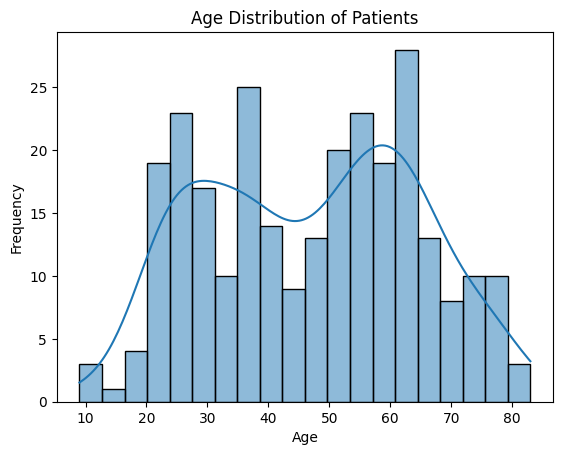

In [17]:
plt.figure()
sns.histplot(eda_df['age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Age Group Analysis

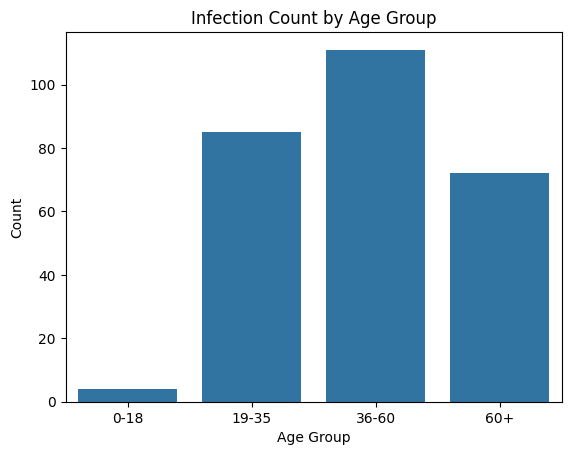

age_group
36-60    111
19-35     85
60+       72
0-18       4
Name: count, dtype: int64


In [18]:
# Create age groups
bins = [0, 18, 35, 60, 100]
labels = ['0-18', '19-35', '36-60', '60+']

eda_df['age_group'] = pd.cut(eda_df['age'], bins=bins, labels=labels)

# Plot
plt.figure()
sns.countplot(data=eda_df, x='age_group', order=labels)
plt.title("Infection Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

# Print values
print(eda_df['age_group'].value_counts())

Region Distribution

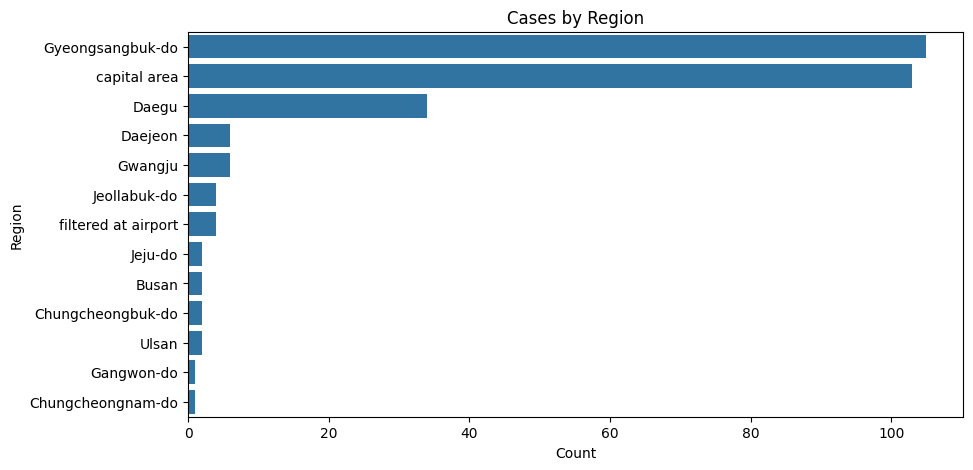

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(data=eda_df, y='region', order=eda_df['region'].value_counts().index)
plt.title("Cases by Region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.show()

Infection Reason Analysis

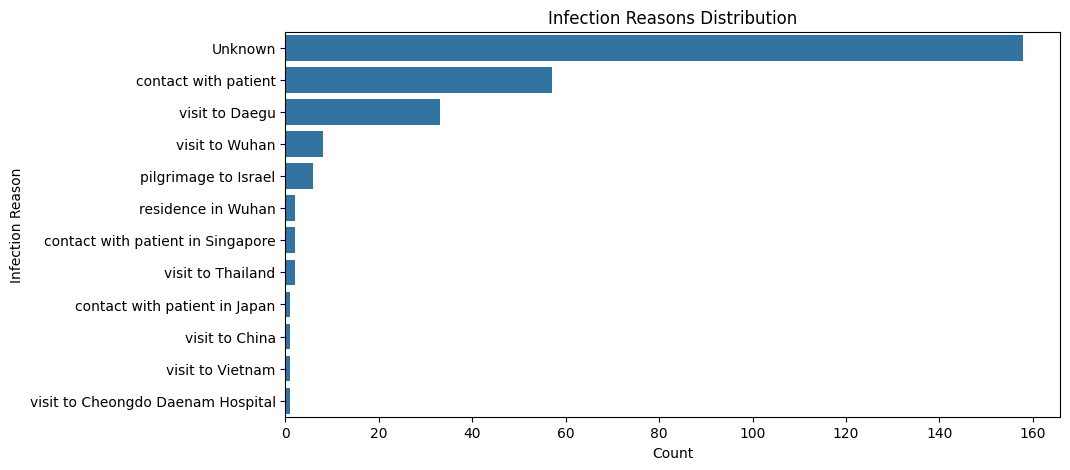

infection_reason
Unknown                              158
contact with patient                  57
visit to Daegu                        33
visit to Wuhan                         8
pilgrimage to Israel                   6
residence in Wuhan                     2
contact with patient in Singapore      2
visit to Thailand                      2
contact with patient in Japan          1
visit to China                         1
visit to Vietnam                       1
visit to Cheongdo Daenam Hospital      1
Name: count, dtype: int64


In [20]:
plt.figure(figsize=(10,5))
sns.countplot(data=eda_df, y='infection_reason',
              order=eda_df['infection_reason'].value_counts().index)

plt.title("Infection Reasons Distribution")
plt.xlabel("Count")
plt.ylabel("Infection Reason")
plt.show()

print(eda_df['infection_reason'].value_counts())

Contact Number Analysis

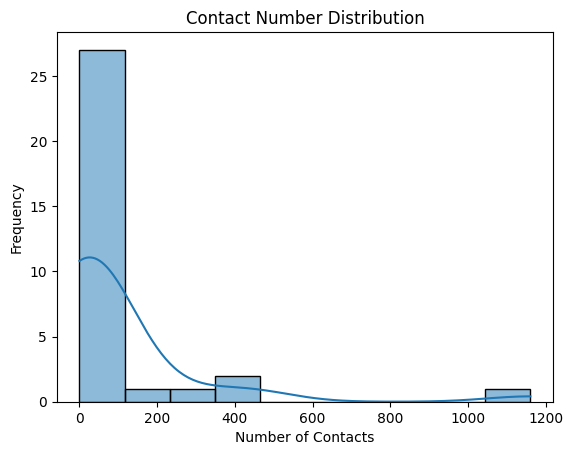

count      32.000000
mean       96.843750
std       224.669522
min         0.000000
25%         2.750000
50%        16.500000
75%        69.750000
max      1160.000000
Name: contact_number, dtype: float64


In [21]:
# Filter only rows with contact_number
contact_df = df[df['contact_number'].notnull()]

plt.figure()
sns.histplot(contact_df['contact_number'], bins=10, kde=True)

plt.title("Contact Number Distribution")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.show()

print(contact_df['contact_number'].describe())

Infection Order Analysis

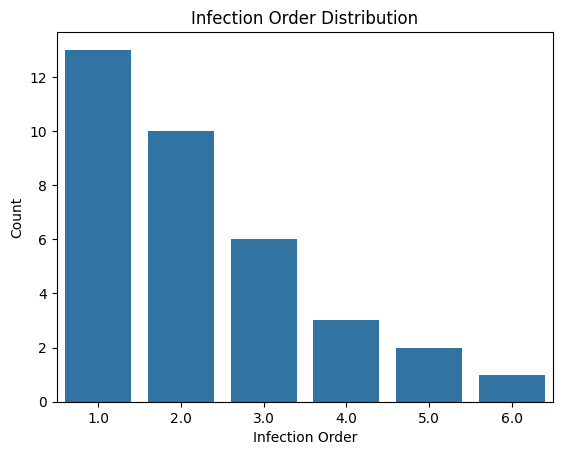

infection_order
1.0    13
2.0    10
3.0     6
4.0     3
5.0     2
6.0     1
Name: count, dtype: int64


In [22]:
infection_df = df[df['infection_order'].notnull()]

plt.figure()
sns.countplot(data=infection_df, x='infection_order')

plt.title("Infection Order Distribution")
plt.xlabel("Infection Order")
plt.ylabel("Count")
plt.show()

print(infection_df['infection_order'].value_counts())

Recovery Time Distribution

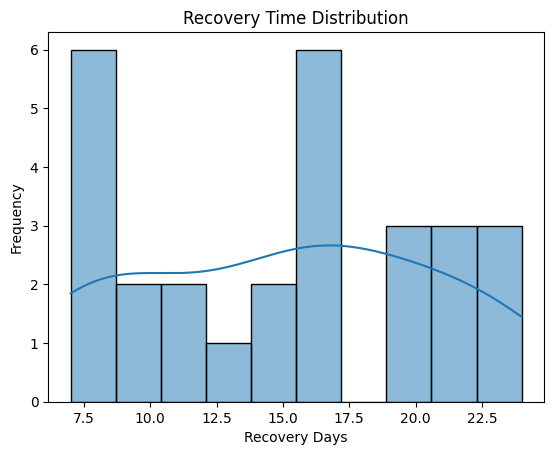

In [23]:
plt.figure()
sns.histplot(recovery_df['recovery_days'], bins=10, kde=True)

plt.title("Recovery Time Distribution")
plt.xlabel("Recovery Days")
plt.ylabel("Frequency")
plt.show()

Recovery vs Gender

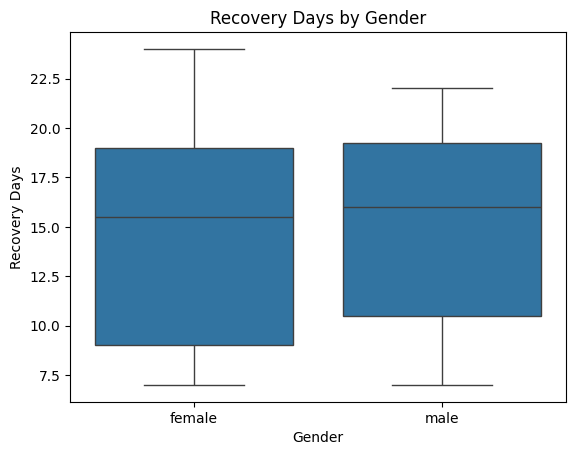

In [24]:
plt.figure()
sns.boxplot(data=recovery_df, x='sex', y='recovery_days')

plt.title("Recovery Days by Gender")
plt.xlabel("Gender")
plt.ylabel("Recovery Days")
plt.show()

Recovery vs Age

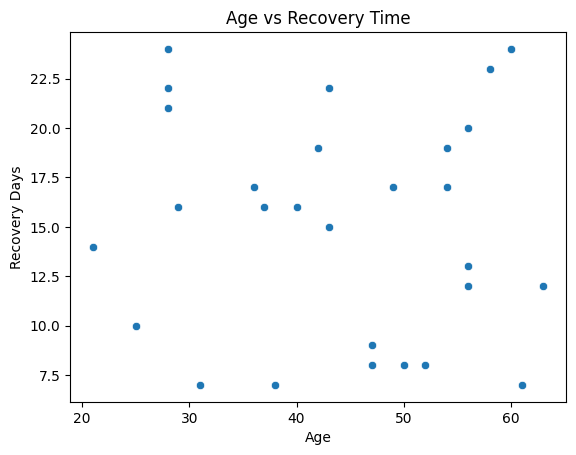

In [25]:
plt.figure()
sns.scatterplot(data=recovery_df, x='age', y='recovery_days')

plt.title("Age vs Recovery Time")
plt.xlabel("Age")
plt.ylabel("Recovery Days")
plt.show()

Recovery vs Age Group

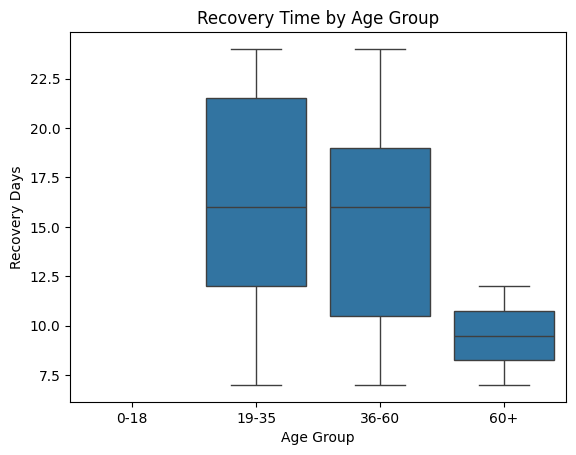

In [26]:
# Create age groups again for recovery_df
bins = [0, 18, 35, 60, 100]
labels = ['0-18', '19-35', '36-60', '60+']

recovery_df['age_group'] = pd.cut(recovery_df['age'], bins=bins, labels=labels)

plt.figure()
sns.boxplot(data=recovery_df, x='age_group', y='recovery_days')

plt.title("Recovery Time by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Recovery Days")
plt.show()

Correlation Analysis

                      age  contact_number  infection_order  recovery_days
age              1.000000        0.174319        -0.075645      -0.076391
contact_number   0.174319        1.000000        -0.180797      -0.244144
infection_order -0.075645       -0.180797         1.000000       0.018192
recovery_days   -0.076391       -0.244144         0.018192       1.000000


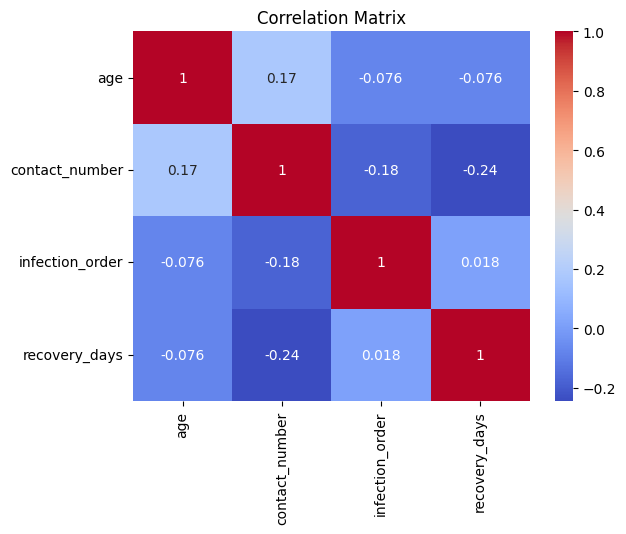

In [27]:
# Select relevant columns
corr_df = recovery_df[['age', 'contact_number', 'infection_order', 'recovery_days']]

# Correlation matrix
corr = corr_df.corr()

print(corr)

# Heatmap
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()